#Consigna 3

#3.1 Configuración del entorno y carga de datos

In [ ]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización (consistencia entre gráficos)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42  # semilla fija para reproducibilidad

In [ ]:
# Carga del dataset
df = pd.read_csv('house-prices-tp.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


#3.2 Inspección del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [ ]:
col_numericas = df.select_dtypes(include=[np.number]).columns.to_list()
col_numericas.remove("MEDV") # Se elimina la variable target de la lista
target = "MEDV"
col_categorica = "CHAS"
if col_categorica in col_numericas:
    col_numericas.remove(col_categorica)

print(f"Variable categórica (dummy): {len(col_categorica)}")
print(f"Variables numéricas: {col_numericas}, Cantidad:{len(col_numericas)}")
print("Variable target: MEDV")

Variable categórica (dummy): 4
Variables numéricas: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'], Cantidad:12
Variable target: MEDV


#3.3 Análisis descriptivo

In [ ]:
descripcion = df.describe().T
# .T transpone la tabla para ver una variable por fila con sus estadísticas descriptivas.

descripcion["Sesgo"] = df[col_numericas + ["MEDV"]].skew()
# Indica qué tan asimétrica es la distribución de cada variable.
# Sesgo cercano a 0: aproximadamente simétrica.
# Sesgo > 0: cola hacia la derecha.
# Sesgo < 0: cola hacia la izquierda.

descripcion["Curtosis"] = df[col_numericas + ["MEDV"]].kurtosis()
# Indica qué tan pesadas son las colas de la distribución respecto a una normal.
# Curtosis cercana a 0: mesocúrtica.
# Curtosis > 0: leptocúrtica, con colas más pesadas.
# Curtosis < 0: platicúrtica, con colas más livianas y distribución más achatada.

descripcion

,count,mean,std,min,25%,50%,75%,max,Sesgo,Curtosis
CRIM,533.0,5.845517,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,534.0,13.197175,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,541.0,11.218725,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
CHAS,533.0,0.090056,0.286531,0.00000,0.00000,0.000000,0.000000,1.0000,NaN,NaN
NOX,532.0,0.560050,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,535.0,6.291839,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,532.0,67.632303,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,541.0,3.944102,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,528.0,9.699379,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,538.0,409.575089,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504


##Criterio de interpretación
Para clasificar el sesgo y la curtosis se toma como referencia el criterio utilizado en el material de análisis exploratorio provisto por la cátedra.
Para el sesgo, se considera aproximadamente simétrica una distribución cuando (|sesgo| < 0.5\); moderadamente asimétrica cuando \(0.5 \le |sesgo| < 1\); y altamente asimétrica cuando (|sesgo| \ge 1\). Para la curtosis, se considera mesocúrtica cuando \(|curtosis| < 0.5\); leptocúrtica cuando la curtosis es positiva y supera dicho umbral; y platicúrtica cuando es negativa y su magnitud supera 0.5.

Luego de realizar una descripción sobre cada variable mediante estadísticas descriptivas, procedemos a analizar de cada una de las variables involucradas detallando características, comportamiento y rango de variación de las mismas.

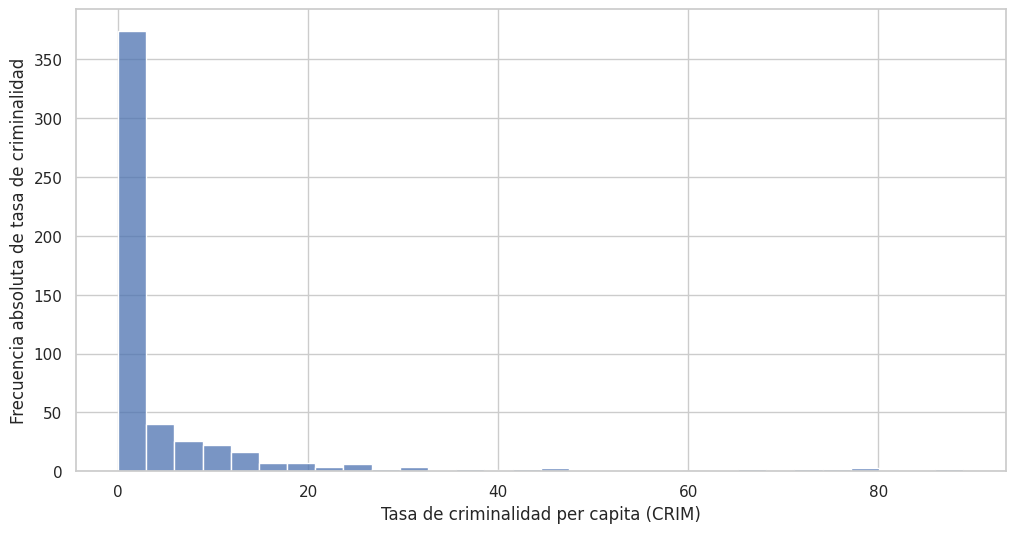

In [ ]:
sns.histplot(df["CRIM"], bins = 30)
plt.ylabel("Frecuencia absoluta de tasa de criminalidad")
plt.xlabel("Tasa de criminalidad per capita (CRIM)");

La variable CRIM (tasa de criminalidad per cápita por ciudad) presenta valores entre 0.006320 y 88.976200, mostrando una variación alta en los datos. Con una media de aproximadamente 5.845 y una mediana de aproximadamente     0.315, lo que nos está indicando que la mayoría de las observaciones se concentra en valores bajos. Además, presenta un sesgo positivo alto con un valor aproximado de 3.746, lo que nos está indicando distribución asimétrica positiva con cola hacia la derecha. A su vez, posee una curtosis también elevada con un valor aproximado de 15.248, lo que indica una distribución leptocúrtica con colas más pesadas.

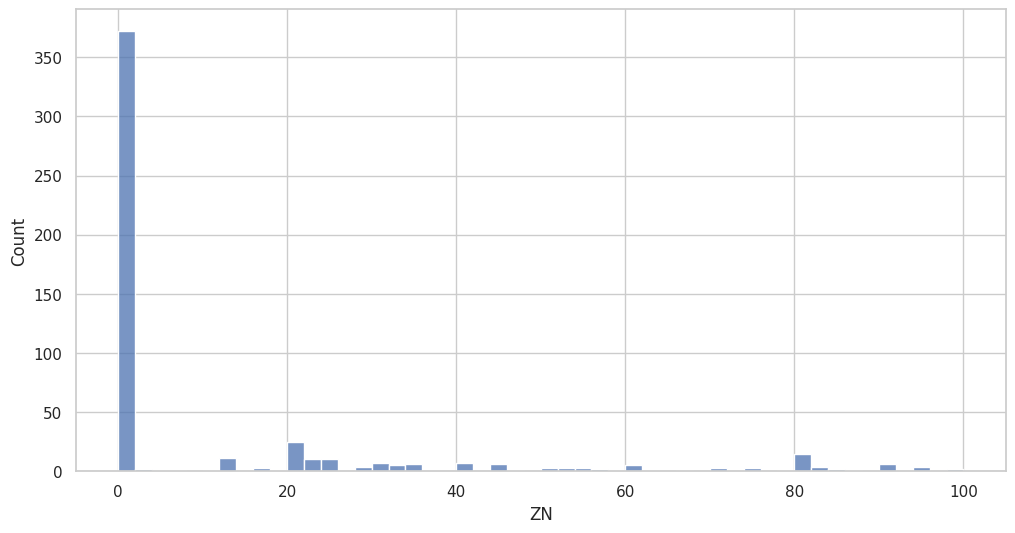

In [ ]:
sns.histplot(df["ZN"], bins = 50);

La variable ZN (proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados) presenta valores entre 0 y 100, indicando una variación alta dentro de la proporción. En el gráfico realizado se puede observar que los valores de la proporción tienen una alta concentración en 0, siendo que Q1 y la mediana(Q2) presentan valores de 0. La media es de aproximadamente 13.197 y una desviación estándar aproximada de 24.902, indicando una dispersión considerable de los datos. La variable presenta un sesgo positivo alto con un valor aproximado de 1.957 indicando que tiene una distribución asimétrica con cola hacia la derecha. A su vez también presenta una curtosis elevada con un valor aproximado de 2.749, indicando presencia de colas pesadas

In [ ]:
df["ZN"].value_counts().sort_index().head()
# De esta manera podemos visualizar mas a detalle no solamente con el grafico la cantidad de valores existentes en la variable ZN

,count
ZN,
0.000000,372
2.897541,1
3.495754,1
5.985746,1
6.528591,1


La variable INDUS (proporción de acres de negocios no minoristas por ciudad) presenta valores entre 0.46 y 27.74, con una media aproximada de 11.22 y una mediana de 9.69. La desviación estándar es de aproximadamente 6.94, mostrando una dispersión moderada de los datos. Presenta un sesgo de aproximadamente 0.30, por lo que puede considerarse aproximadamente simétrica. A su vez, su curtosis es de aproximadamente -1.21, indicando una distribución platicúrtica, más achatada y con colas más livianas respecto de una distribución normal.

La variable CHAS (variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)) es una variable dummy que explica si el tramo limita con el río Charles o no. Habiendo realizado un calculo, podemos observar que aproximadamente el 87.23% de los datos obtenidos no limitan con el río, en cambio aproximadamente un 8.6% si limita con el río y un aproximado de 4.13% de valores faltantes

In [ ]:
df["CHAS"].value_counts(normalize=True, dropna=False).mul(100)

,proportion
CHAS,
0.0,87.230216
1.0,8.633094
NaN,4.136691


La variable NOX (concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]) tiene un rango entre 0.38500 y 0.8710. A su vez, presenta una media aproximada de 0.56 y un desvio estandar aproximado de 0.119, indicando una baja variacion de los datos con respecto a su escala. Junto a esto, tiene un sesgo positivo aproximado de 0.69, con una asimetria moderada hacia la cola derecha y una curtosis aproximada de -0.22 lo que indica una distribución más achatada (platicurtica)

La variable RM (número promedio de habitaciones por vivienda) posee un rango entre 3.56100 y 8.78. Junto a esto, tiene una media aproximada de 6.29 y una desviacion estandar aproximada de 0.78, lo que indica una baja variación entre los datos con respecto a su escala. A su vez, posee un sesgo aproximado de 0.37, indicando una distribución aproximadamente simétrica y una curtosis aproximada de 1.55, indicando una distribución leptocúrtica con colas pesadas.

La variable AGE (proporción de unidades ocupadas por sus propietarios construidas antes de 1940) posee un rango entre 2.9 y 100, indicando una variación amplia dentro de la proporción. Junto a esto, posee una media aproximada de 67.63 y un desvio estandar aproximado de 28.46, indicando la presencia de valores extremos positivos por el alto valor de la media. A su vez, posee un sesgo aproximado de -0.55, indicando una distribución levemente asimétrica hacia la derecha

La variable DIS (distancias ponderadas a cinco centros de empleo de Boston) posee un rango entre 1.1296 y 12.1265. Junto a esto, tiene una media aproximada de 3.94 y una desviación estándar aproximada de 2.25, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 1.08, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de 0.71, indicando una distribución leptocúrtica con colas algo más pesadas que una distribución normal.

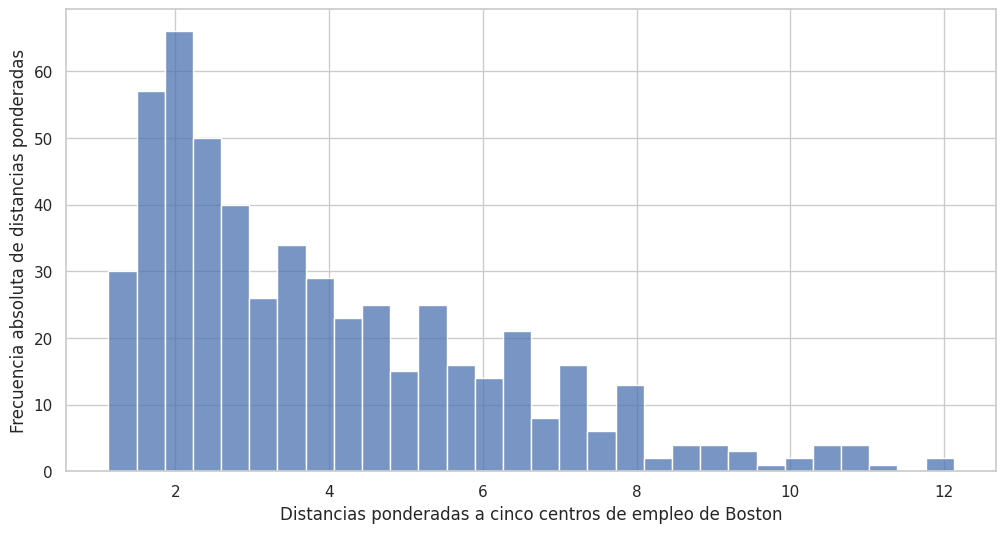

In [ ]:
sns.histplot(df["DIS"], bins = 30);
plt.xlabel("Distancias ponderadas a cinco centros de empleo de Boston")
plt.ylabel("Frecuencia absoluta de distancias ponderadas");

La variable RAD (índice de accesibilidad a las autopistas radiales) posee un rango entre 1 y 24. Junto a esto, tiene una media aproximada de 9.70 y una desviación estándar aproximada de 8.68, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 0.95, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de -0.95, indicando una distribución platicúrtica, más achatada y con colas más livianas que una distribución normal.

La variable TAX (tasa de impuesto sobre la propiedad a valor completo por $10,000) posee un rango entre 187 y 711. Junto a esto, tiene una media aproximada de 409.58 y una desviación estándar aproximada de 167.69, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 0.63, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de -1.17, indicando una distribución platicúrtica, más achatada y con colas más livianas que una distribución normal.

La variable PTRATIO (proporción alumno-maestro por ciudad) posee un rango entre 12.6 y 22. Junto a esto, tiene una media aproximada de 18.43 y una desviación estándar aproximada de 2.19, indicando una variación relativamente baja de los datos con respecto a su escala. A su vez, posee un sesgo negativo aproximado de -0.79, indicando una distribución asimétrica con cola hacia la izquierda. También presenta una curtosis aproximada de -0.30, indicando una distribución levemente más achatada respecto de una normal.

La variable B posee un rango entre 0.32 y 396.9. Junto a esto, tiene una media aproximada de 347.81 y una desviación estándar aproximada de 99.64, indicando una dispersión considerable de los datos. A su vez, posee un sesgo negativo alto de aproximadamente -2.40, indicando una distribución fuertemente asimétrica con cola hacia la izquierda. También presenta una curtosis elevada de aproximadamente 4.50, indicando una distribución leptocúrtica con colas pesadas.

Text(0, 0.5, 'Frecuencia absoluta')

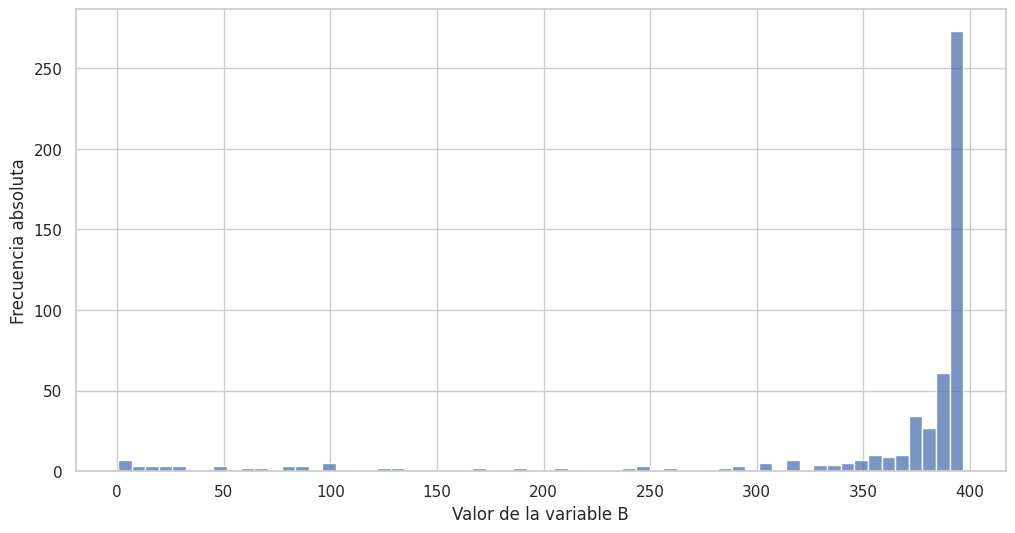

In [ ]:
sns.histplot(df["B"]);
plt.xlabel("Valor de la variable B")
plt.ylabel("Frecuencia absoluta")

La variable LSTAT (% de población de menor estatus socioeconómico) posee un rango entre 1.73 y 37.97. Junto a esto, tiene una media aproximada de 13.03 y una desviación estándar aproximada de 7.58, indicando una dispersión considerable de los datos con respecto a su escala. A su vez, posee un sesgo positivo aproximado de 0.95, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de 0.48, cercana a una distribución mesocúrtica.

La variable MEDV (valor mediano de las viviendas ocupadas por sus propietarios, en miles de dólares) posee un rango entre 5 y 50. Junto a esto, tiene una media aproximada de 22.75 y una desviación estándar aproximada de 9.49, indicando una dispersión considerable de los valores. A su vez, posee un sesgo positivo aproximado de 1.06, indicando una distribución asimétrica con cola hacia la derecha. También presenta una curtosis aproximada de 1.17, indicando una distribución leptocúrtica con colas pesadas.

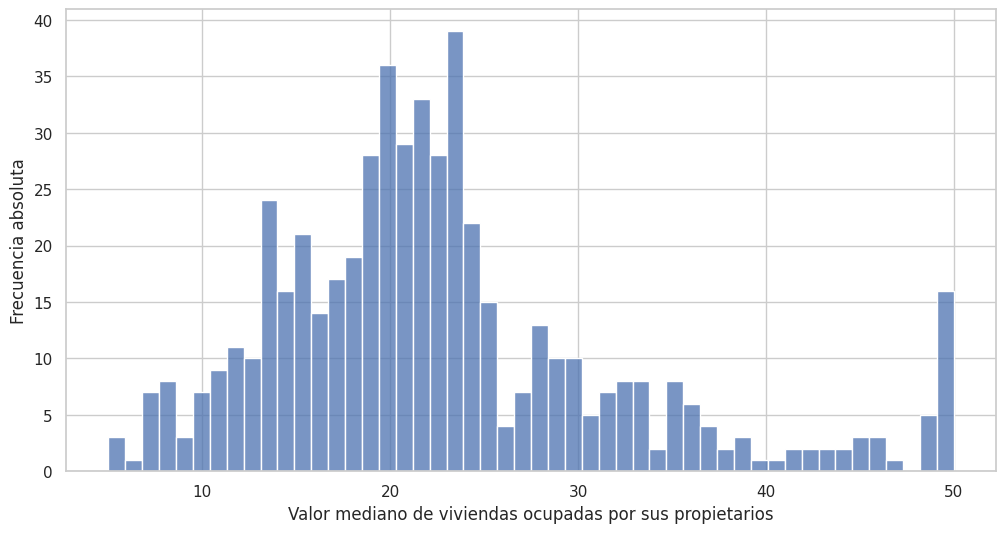

In [ ]:
sns.histplot(df["MEDV"], bins = 50)
plt.xlabel("Valor mediano de viviendas ocupadas por sus propietarios")
plt.ylabel("Frecuencia absoluta");

Las variables CRIM, B, ZN, DIS y MEDV presentan sesgo marcado (|sesgo| > 1). CRIM y B son las más extremas:

In [ ]:
descripcion


,count,mean,std,min,25%,50%,75%,max,Sesgo,Curtosis
CRIM,533.0,5.845517,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,534.0,13.197175,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,541.0,11.218725,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
CHAS,533.0,0.090056,0.286531,0.00000,0.00000,0.000000,0.000000,1.0000,NaN,NaN
NOX,532.0,0.560050,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,535.0,6.291839,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,532.0,67.632303,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,541.0,3.944102,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,528.0,9.699379,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,538.0,409.575089,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504


#3.4 Análisis y decisión sobre datos faltantes

In [ ]:
# Mostramos el porcentaje de nulos de cada variable respecto al total y la cantidad de faltantes en cada variable
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
PTRATIO,28,5.04
RAD,28,5.04
NOX,24,4.32
AGE,24,4.32
CHAS,23,4.14
CRIM,23,4.14
LSTAT,22,3.96
B,22,3.96
ZN,22,3.96
RM,21,3.78


In [ ]:
# Mostramos la cantidad de filas con su respectiva proporcion en faltantes
porcentaje_nulos_fila = df.isna().mean(axis=1) * 100
porcentaje_nulos_fila.value_counts().sort_index()

,count
0.000000,506
7.142857,5
14.285714,3
21.428571,11
28.571429,3
35.714286,3
42.857143,2
50.000000,5
57.142857,4
64.285714,4


Luego de revisar los valores faltantes respecto al total de los datos del dataset, consideramos eliminar las filas donde la variable target (MEDV) posee un valor faltante. Tomamos esta decisión porque imputar valores en la variable objetivo implicaría introducir datos artificiales justamente en la variable que el modelo debe aprender a predecir, lo que podría afectar el resultado del entrenamiento.

In [ ]:
df = df.dropna(subset=["MEDV"])

In [ ]:
# Recalculamos cantidad y porcentaje de nulos por variable luego de eliminar los faltantes en la variable MEDV
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
RAD,12,2.24
ZN,11,2.06
CRIM,11,2.06
AGE,11,2.06
CHAS,9,1.68
B,9,1.68
NOX,9,1.68
PTRATIO,9,1.68
TAX,9,1.68
LSTAT,9,1.68


In [ ]:
porcentaje_faltantes_fila = df.isna().mean(axis=1) * 100
porcentaje_faltantes_fila.value_counts().sort_index()

,count
0.000000,506
7.142857,5
14.285714,3
21.428571,9
28.571429,2
35.714286,2
42.857143,1
50.000000,4
57.142857,2
64.285714,1


In [ ]:
# Eliminar filas con mas del 50% de columnas faltantes
pct_nulos_fila = df.isnull().sum(axis=1) / df.shape[1] * 100

print('Filas con mas del 50% de columnas faltantes:', (pct_nulos_fila > 50).sum())

df = df[pct_nulos_fila <= 50]

In [ ]:
532 / 556 *100

95.68345323741008

importarla e instalar catboost(usar p categoricas)

usar k means(usar p continuas) hay que iterar k veces para usarla